In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap, Normalize
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)          
# Remove rows where 'fileID' is in removeFileID
df_info_filtered = df_info[~df_info['fileID'].isin(removeFileID)]

# # Assign the filtered DataFrame back to df_info
df_info = df_info_filtered

In [2]:


df_best = pd.read_csv('tables/best_groundingline_ms_method_per_model.csv')
df_best['melt_sensetivity_FilchnerRonne']=df_best['melt_sensetivity_Filchner_Ronne']

df_m2100 = pd.read_csv('./tables/averegeshelfmelt_2100.csv')
df_m2200 = pd.read_csv('./tables/averegeshelfmelt_2200.csv')
df_m2300 = pd.read_csv('./tables/averegeshelfmelt_2300.csv')


df_bmb2100 = pd.read_csv('./tables/totalshelfmelt_2100.csv')
df_bmb2200 = pd.read_csv('./tables/totalshelfmelt_2200.csv')
df_bmb2300 = pd.read_csv('./tables/totalshelfmelt_2300.csv')
                         
df_dslr2100 = pd.read_csv('./tables/dslc_anom_2100.csv')
df_dslr2200 = pd.read_csv('./tables/dslc_anom_2200.csv')
df_dslr2300 = pd.read_csv('./tables/dslc_anom_2300.csv')

df_tf2100 = pd.read_csv('./tables/thermalforcing_2100.csv')
df_tf2200 = pd.read_csv('./tables/thermalforcing_2200.csv')
df_tf2300 = pd.read_csv('./tables/thermalforcing_2300.csv')

df_iareafl2100 = pd.read_csv('./tables/iareafl_2100.csv')
df_iareafl2200 = pd.read_csv('./tables/iareafl_2200.csv')
df_iareafl2300 = pd.read_csv('./tables/iareafl_2300.csv')

df_iareagr2100_change = pd.read_csv('./tables/pchange_iareagr_2100.csv')
df_iareagr2200_change = pd.read_csv('./tables/pchange_iareagr_2200.csv')
df_iareagr2300_change = pd.read_csv('./tables/pchange_iareagr_2300.csv')

dfds = [
    df_m2100 ,
df_m2200 ,
df_m2300 ,
df_bmb2100,
df_bmb2200 ,
df_bmb2300  ,                     
df_tf2100 ,
df_tf2200 ,
df_tf2300 ,
df_iareafl2100, 
df_iareafl2200 ,
df_iareafl2300 ,
df_iareagr2100_change ,
df_iareagr2200_change,
df_iareagr2300_change,


]

for df_ms in dfds:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
    
regions = ['AIS',
 'WestAntarctica',
 'EastAntarctica',
 'Peninsula',
           'Amundsen',
 'Ross',
 'FilchnerRonne']
regions_keys ={}
regions_keys['AIS'] = ['']
regions_keys['WestAntarctica']=['_region_1']
regions_keys['EastAntarctica']=['_region_2']
regions_keys['Peninsula']=['_region_3']
regions_keys['Amundsen']=['_sector_4']
regions_keys['Ross']=['_sector_2','_sector_6',]
regions_keys['FilchnerRonne']= ['_sector_5','_sector_11']

Models = df_best.Model.values

###  let us look at all models but not UCSD ISSM and ILP KIriBU1 because those are the only ones showing shelf growth. or maybe leave them in for now

In [3]:
msk = (Models != 'UCSD_ISSM') &  ( Models != 'ULB_fETISh-KoriBU1')

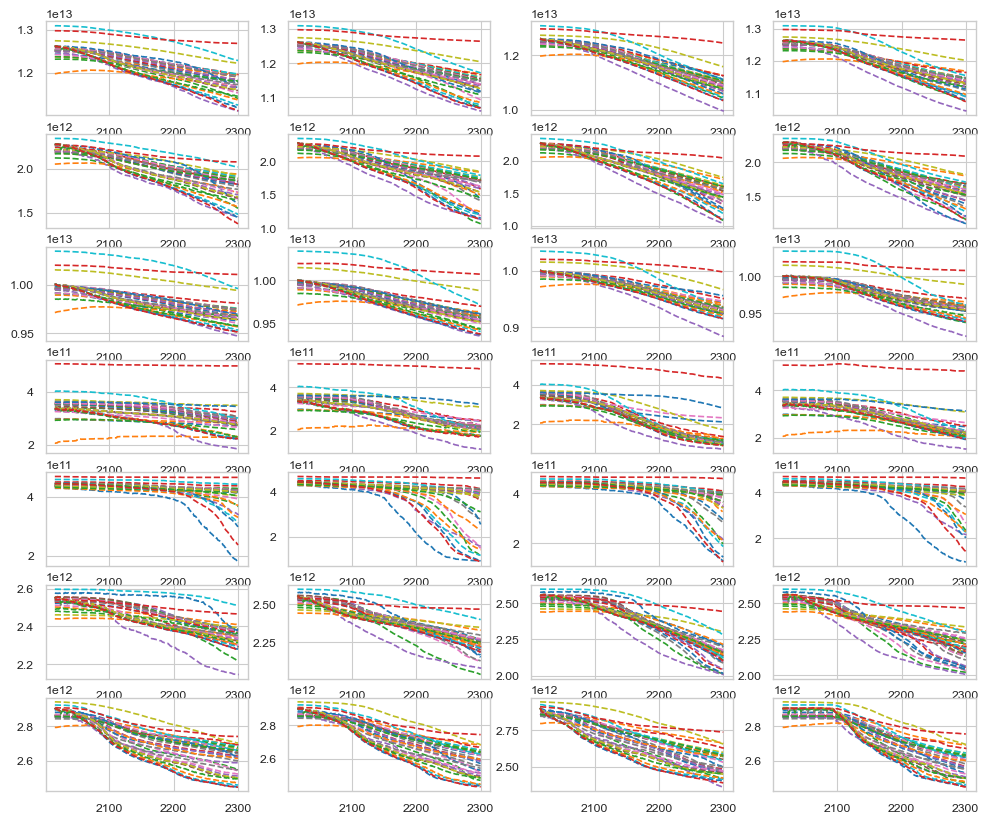

In [4]:
f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[msk]
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for Model in Models[msk]:
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y,linestyle = '--' ,label = Model)
                
   


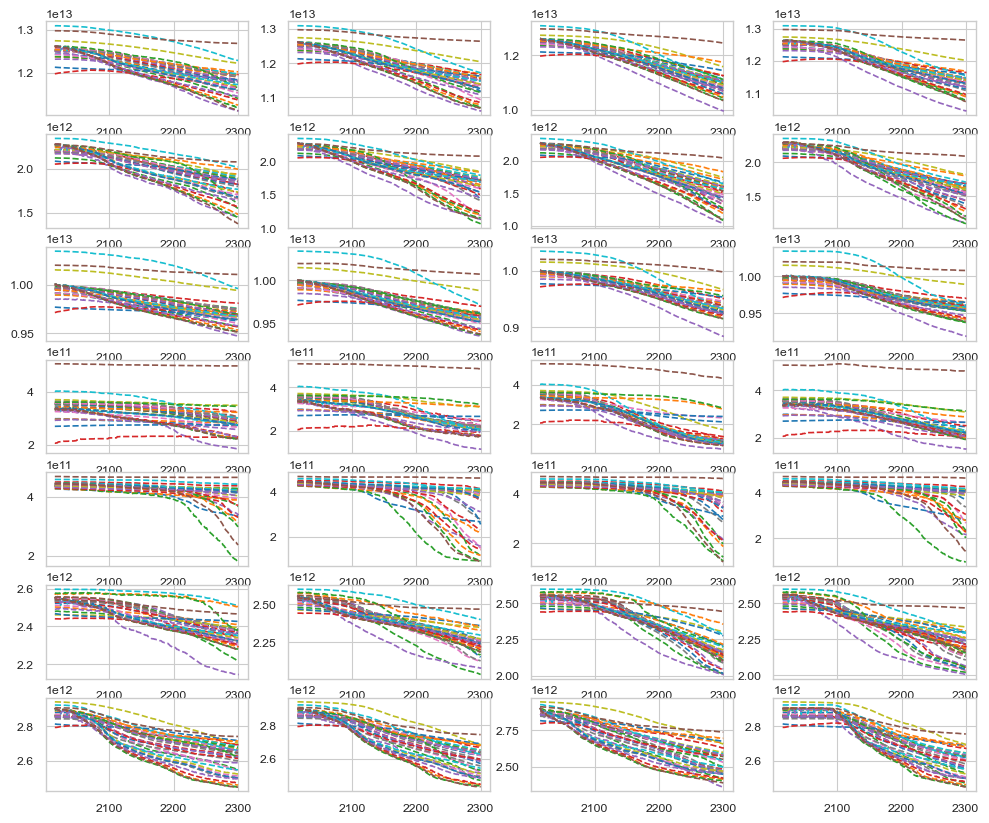

In [5]:
f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for Model in Models:
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            

           
           
       
            ax.plot(d.time.values,y,linestyle = '--' ,label = Model)
                
   


relative changes

In [6]:
f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for Model in Models:
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           

           
           
       
            ax.plot(d.time.values,y,linestyle = '--' ,label = Model)
        ax2[i,0].set_ylabel(region)   
   


In [7]:
### check different melt param

In [8]:
param_u =np.unique(df_best['parameterization'])
marker_u = ['^','v','*','s','P','p']
cols_u = ['black','steelblue','orange','crimson','green','cyan']
dic_marker = {}
dic_colors_param = {}

for i,key in enumerate(param_u):
    dic_marker[key]= marker_u[i]
    dic_colors_param[key]= cols_u[i]
markers = []
marker_nomodel=[]
colors_param = []
colors_param_nomodel = []

msk = df_best.Model.values != 'VUW_PISM2_s1'
for key in df_best['parameterization']:
    markers.append(dic_marker[key])
    colors_param.append(dic_colors_param[key])
for key in df_best['parameterization'][msk]:
    marker_nomodel.append(dic_marker[key])
    colors_param_nomodel.append(dic_colors_param[key])
    

In [9]:
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_param.items()]



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            col = colors_param[k]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label = Model)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('grounded area (%)')
   
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


### by ice front treatemnt

In [45]:
df_info[df_info.Experiment == exp]['ice front'].values

array(['MH', 'Fix', 'MH', 'MH', 'MH', 'RO', 'RO', 'RO', 'RO', 'RO', 'RO',
       'RO', 'RO', 'RO', 'RO', 'RO', 'RO', 'RO', 'StR', 'VM', 'Fix',
       'Div', 'Div', 'RO', 'Fix', 'MH', 'StR', 'StR', 'StR', 'StR', 'StR',
       'StR', 'StR', 'StR', 'StR', 'StR'], dtype=object)

In [46]:
icefront_u =np.unique(df_info['ice front'])
cols_u = ['black','steelblue','orange','crimson','green','cyan']

dic_colors_icefront = {}

for i,key in enumerate(icefront_u):

    dic_colors_icefront[key]= cols_u[i]

colors_icefront= []

msk = df_best.Model.values != 'VUW_PISM2_s1'
icefronts_per_model = df_info[df_info.Experiment == exp]['ice front'].values
for key in icefronts_per_model:
   
    colors_icefront.append(dic_colors_icefront[key])


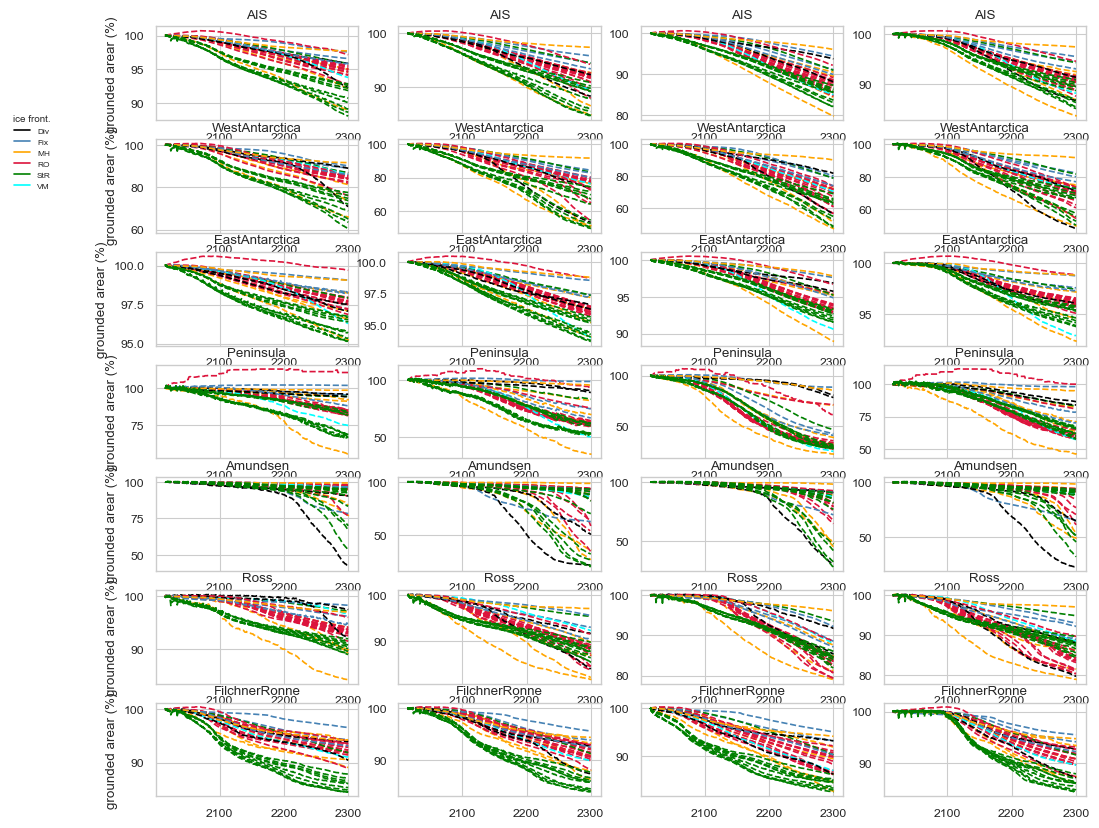

In [47]:
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_icefront.items()]



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            col = colors_icefront[k]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label = Model)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('grounded arear (%)')
   
f.legend(handles=legend_elements, title='ice front.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


### for some there is only one combination of melt param and ice front treate ment so it is hard to tell which  is the influencing part, let us check the combinations

In [48]:

icefront_param_per_model =icefronts_per_model +" "+df_best['parameterization'].values.tolist()

icefront_param_u =np.unique(icefront_param_per_model)
cols_u = ['black','brown','blue','steelblue','orange','fuchsia','crimson','red','olive','green','cyan','pink']

dic_colors_icefrontparam = {}

for i,key in enumerate(icefront_param_u):

    dic_colors_icefrontparam[key]= cols_u[i]

colors_icefront_param= []

# msk = df_best.Model.values != 'VUW_PISM2_s1'
# icefronts_per_model = df_info[df_info.Experiment == exp]['ice front'].values
for key in icefront_param_per_model:
   
    colors_icefront_param.append(dic_colors_icefrontparam[key])


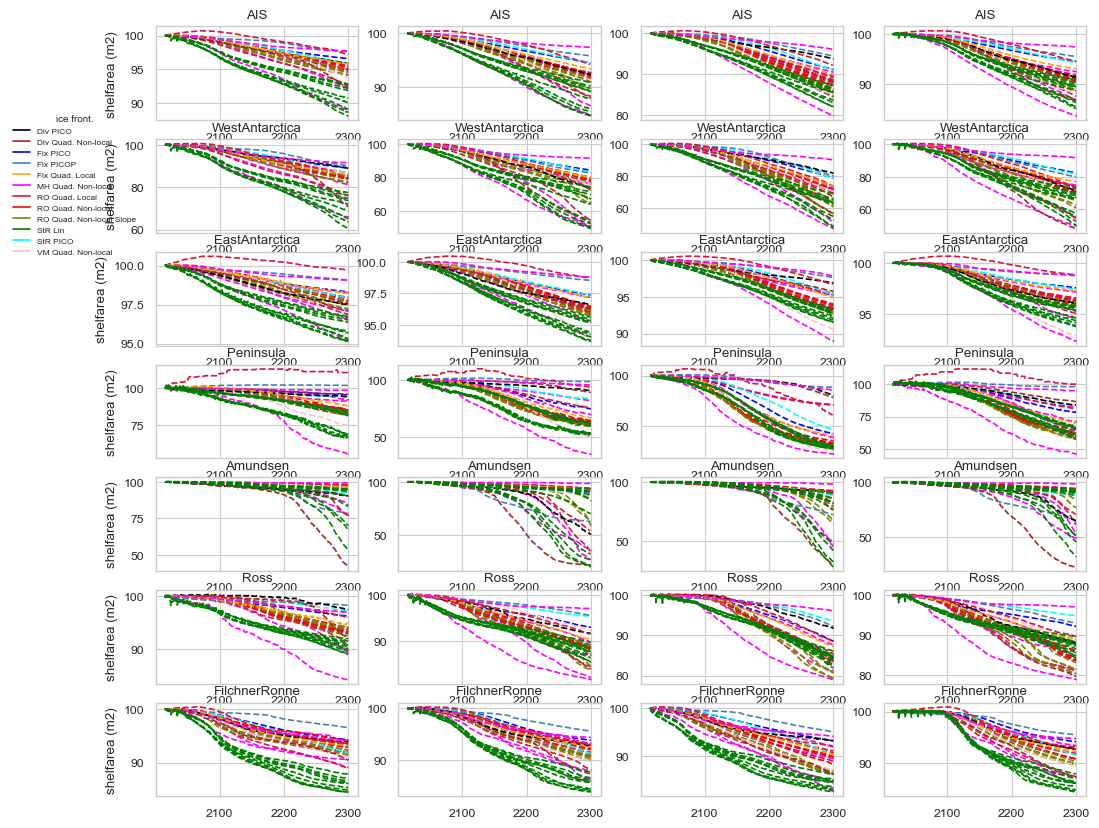

In [49]:
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_icefrontparam.items()]



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            col = colors_icefront_param[k]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label = Model)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   
f.legend(handles=legend_elements, title='ice front.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=6, title_fontsize=7,frameon=False)


In [50]:
### doe the same groups apply?



In [87]:
# Test with pic:

models_group1=['VUW_PISM1', 'VUW_PISM1_s1', 'VUW_PISM1_s2', 'VUW_PISM1_s3' ,'VUW_PISM1_s4' ,'VUW_PISM2',\
               'VUW_PISM2_s1', 'VUW_PISM2_s2', 'VUW_PISM2_s3', 'VUW_PISM2_s4','ULB_fETISh-KoriBU2', ]
models_group2 = ['DC_ISSM' ,'VUB_AISMPALEO','NCAR_CISM1' ,'NORCE_CISM3-MAR364-ERA-t1-nonlocal',\
                 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' ,'NORCE_CISM5-MAR364-ERA-t1-nonlocal','NCAR_CISM2',\
                 'NORCE_CISM3-MAR364-ERA-t1-local' ,'NORCE_CISM4-MAR364-ERA-t1-local' ,\
                 'NORCE_CISM5-MAR364-ERA-t1-local','NORCE_CISM2-MAR364-ERA-t1',\
                 'NORCE_CISM3-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-JRA-t1',\
                 'NORCE_CISM5-MAR364-ERA-t1','UTAS_ElmerIce','UCM_Yelmo']
models_group3=['IGE_ElmerIce', 'PIK_PISM','ULB_fETISh-KoriBU1']
models_group4 =['UNN_Ua','UCSD_ISSM','LSCE_GRISLI2' ,'LSCE_GRISLI']

models_group5=['ILTS_SICOPOLIS' ]
models_groups = [models_group1,models_group2,models_group3,models_group4,models_group5]


n = 0

all_model_groups = []
for group in models_groups:
    for m in group:
        all_model_groups.append(m)
    n= n+len(group);
    

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in all_model_groups:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            


all_groups =[models_group1,models_group2,models_group3,models_group4,models_group5]


cols_u = ['black','blue','cyan','fuchsia','green','orange']

groups_cat = np.zeros_like(Models)

for i,Model in enumerate(Models):
    for j, group in enumerate(all_groups):
        for gmodel in group:
           
            if gmodel == Model:
                groups_cat[i]=j
                
groups_cat


dic_colors_groupcat = {}
for i in range(4):
    key = 'group_'+str(i+1)
    dic_colors_groupcat[key]=cols_u[i]

#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0],  color=col, label=param)
                   for param, col in dic_colors_groupcat.items()]




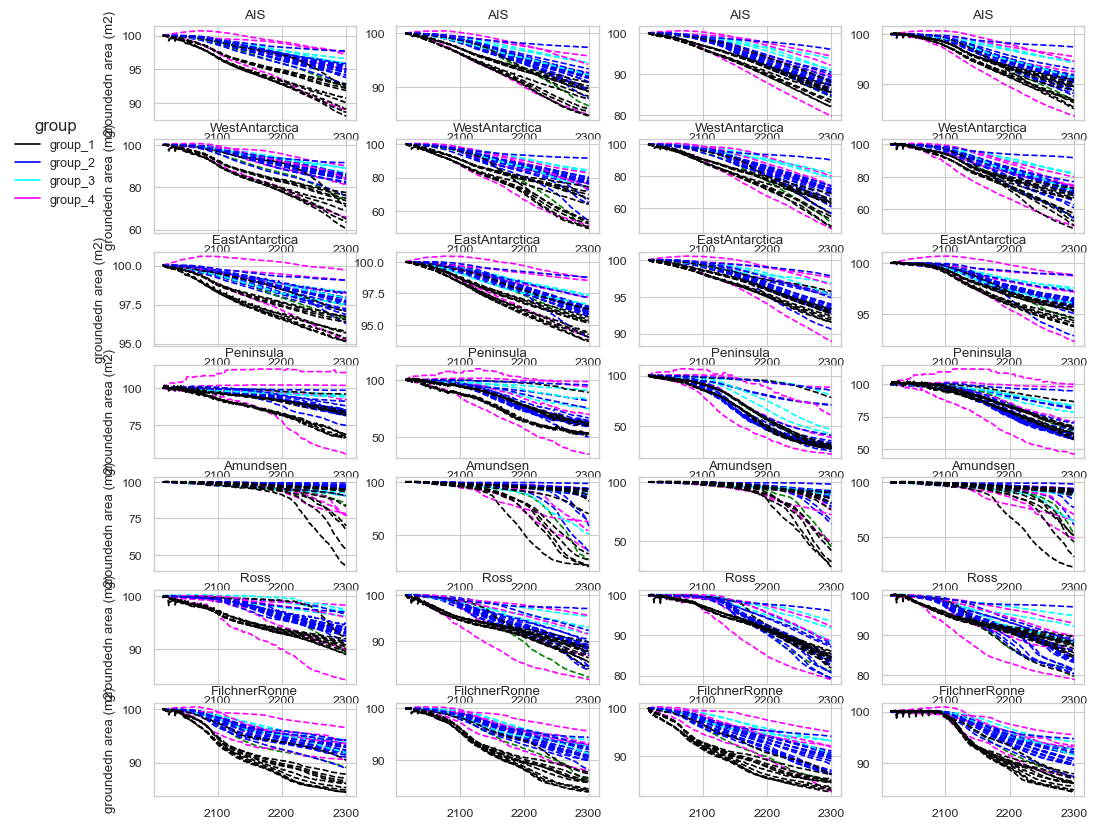

In [88]:
f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values
    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            col = cols_u[groups_cat[k]]
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
           
            ax.plot(d.time.values,y,color = col,linestyle = '--' )
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('groundedn area (m2)')
   
f.legend(handles=legend_elements, title='group', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=9, title_fontsize=12,frameon=False)


Div PICO
Models ['ULB_fETISh-KoriBU1']
Div Quad. Non-local
Models ['ULB_fETISh-KoriBU2']
Fix PICO
Models ['IGE_ElmerIce']
Fix PICOP
Models ['UCSD_ISSM']
Fix Quad. Local
Models ['UTAS_ElmerIce']
MH Quad. Non-local
Models ['DC_ISSM' 'ILTS_SICOPOLIS' 'LSCE_GRISLI2' 'LSCE_GRISLI' 'VUB_AISMPALEO']
RO Quad. Local
Models ['NCAR_CISM2' 'NORCE_CISM3-MAR364-ERA-t1-local'
 'NORCE_CISM4-MAR364-ERA-t1-local' 'NORCE_CISM5-MAR364-ERA-t1-local'
 'UNN_Ua']
RO Quad. Non-local
Models ['NCAR_CISM1' 'NORCE_CISM3-MAR364-ERA-t1-nonlocal'
 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' 'NORCE_CISM5-MAR364-ERA-t1-nonlocal']
RO Quad. Non-local Slope
Models ['NORCE_CISM2-MAR364-ERA-t1' 'NORCE_CISM3-MAR364-ERA-t1'
 'NORCE_CISM4-MAR364-ERA-t1' 'NORCE_CISM4-MAR364-JRA-t1'
 'NORCE_CISM5-MAR364-ERA-t1']
StR Lin
Models ['VUW_PISM1' 'VUW_PISM1_s1' 'VUW_PISM1_s2' 'VUW_PISM1_s3' 'VUW_PISM1_s4'
 'VUW_PISM2' 'VUW_PISM2_s1' 'VUW_PISM2_s2' 'VUW_PISM2_s3' 'VUW_PISM2_s4']
StR PICO
Models ['PIK_PISM']
VM Quad. Non-local
Models ['UCM_Yelm

[Text(0, 0, 'Div PICO'),
 Text(1, 0, 'Div Quad. Non-local'),
 Text(2, 0, 'Fix PICO'),
 Text(3, 0, 'Fix PICOP'),
 Text(4, 0, 'Fix Quad. Local'),
 Text(5, 0, 'MH Quad. Non-local'),
 Text(6, 0, 'RO Quad. Local'),
 Text(7, 0, 'RO Quad. Non-local'),
 Text(8, 0, 'RO Quad. Non-local Slope'),
 Text(9, 0, 'StR Lin'),
 Text(10, 0, 'StR PICO'),
 Text(11, 0, 'VM Quad. Non-local')]

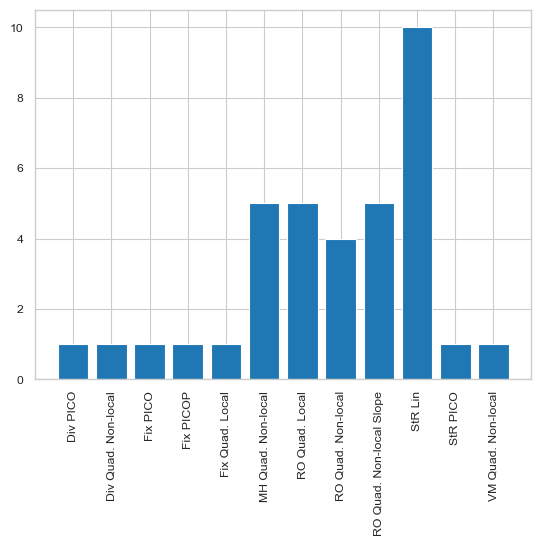

In [71]:
f,ax = plt.subplots(1,1)
counts = np.zeros(len(icefront_param_u))
for i,combi in enumerate(icefront_param_u):
    counts[i]=icefront_param_per_model[combi == icefront_param_per_model].size
    print(combi)
    print('Models',Models[combi == icefront_param_per_model])
    
ax.bar(np.arange(len(counts)),counts)
ax.set_xticks(np.arange(len(counts)))       
ax.set_xticklabels(icefront_param_u, rotation=90)

## let us look at the three combination that are used by different models
1. MH Quad. Non-local <br>
Models ['DC_ISSM' 'ILTS_SICOPOLIS' 'LSCE_GRISLI2' 'LSCE_GRISLI' 'VUB_AISMPALEO']<br>
2. RO Quad. Local<br>
Models ['NCAR_CISM2' 'NORCE_CISM3-MAR364-ERA-t1-local'
 'NORCE_CISM4-MAR364-ERA-t1-local' 'NORCE_CISM5-MAR364-ERA-t1-local'
 'UNN_Ua']<br>
3. RO Quad. Non-local<br>
Models ['NCAR_CISM1' 'NORCE_CISM3-MAR364-ERA-t1-nonlocal'
 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' 'NORCE_CISM5-MAR364-ERA-t1-nonlocal']<br>

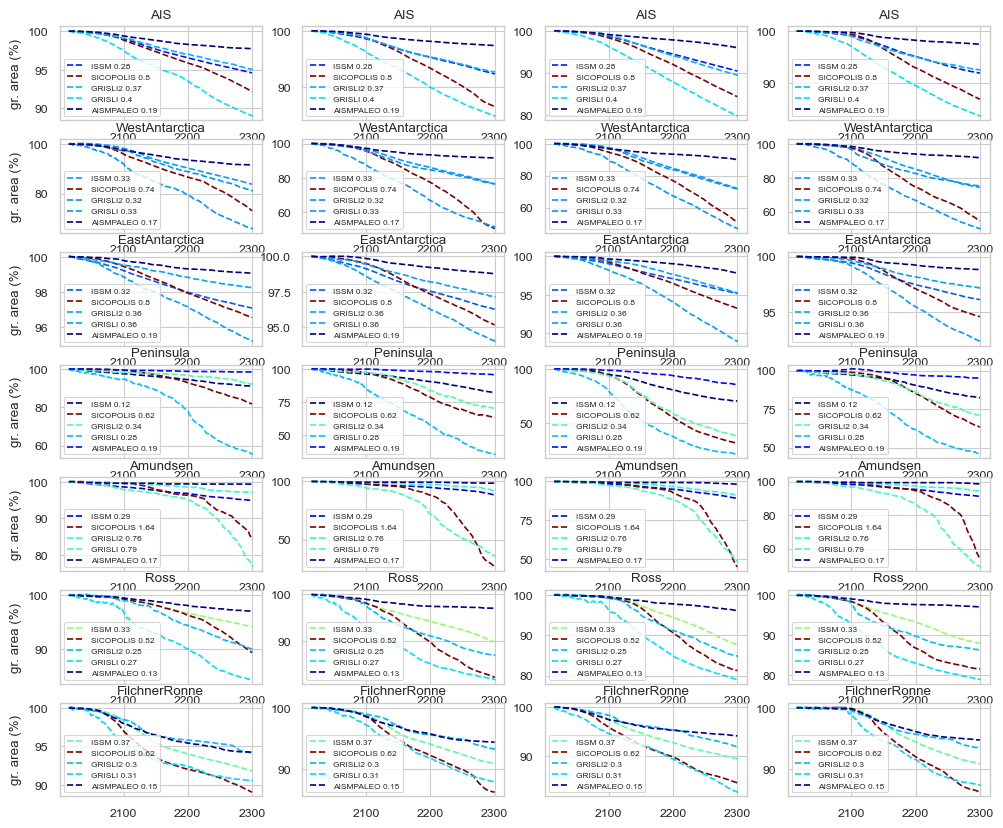

In [72]:
# 1.  MH Quad. Non-local 

Models_1 = ['DC_ISSM', 'ILTS_SICOPOLIS', 'LSCE_GRISLI2', 'LSCE_GRISLI', 'VUB_AISMPALEO']

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[1]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr. area (%)')
   




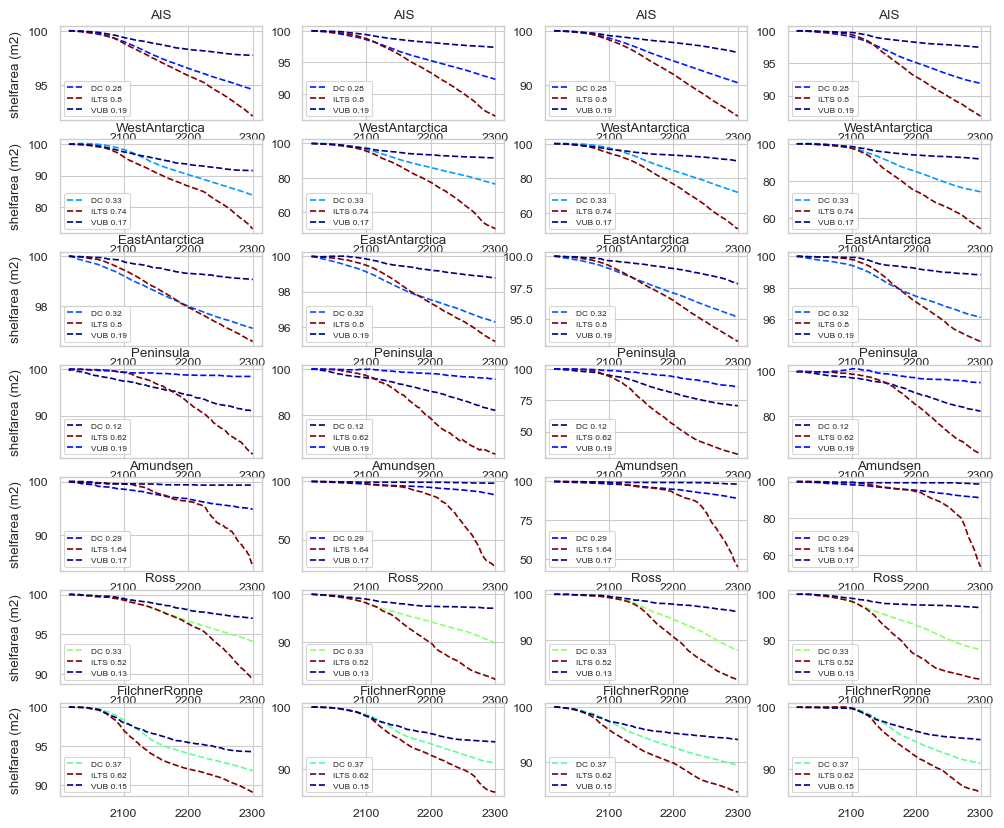

In [73]:
# 1.  MH Quad. Non-local no GRSILI

Models_1 = ['DC_ISSM', 'ILTS_SICOPOLIS', 'VUB_AISMPALEO']

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
#     cmap = plt.get_cmap('YlOrRd')
    cmap = plt.get_cmap('jet')
    
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models[mask_special_model]):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   




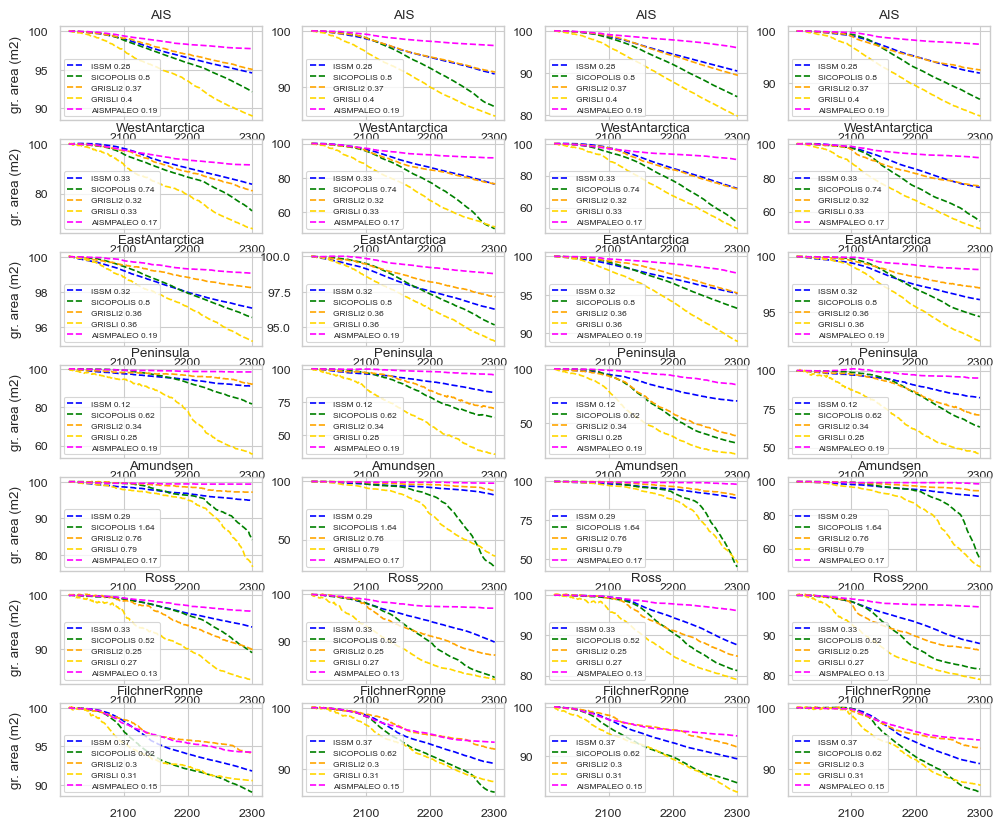

In [74]:
# 1.  MH Quad. Non-local 

Models_1 = ['DC_ISSM', 'ILTS_SICOPOLIS', 'LSCE_GRISLI2', 'LSCE_GRISLI', 'VUB_AISMPALEO']

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            

colors_dic = {}
colors_dic['DC_ISSM']= 'blue'
colors_dic['ILTS_SICOPOLIS']= 'green'
colors_dic['VUB_AISMPALEO']= 'fuchsia'
colors_dic['LSCE_GRISLI2']= 'orange'
colors_dic['LSCE_GRISLI']= 'gold'



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('YlOrRd')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
       
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            ms = np.round(ms_models[k],2)
            col =colors_dic[Model]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[1]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr. area (m2)')
   




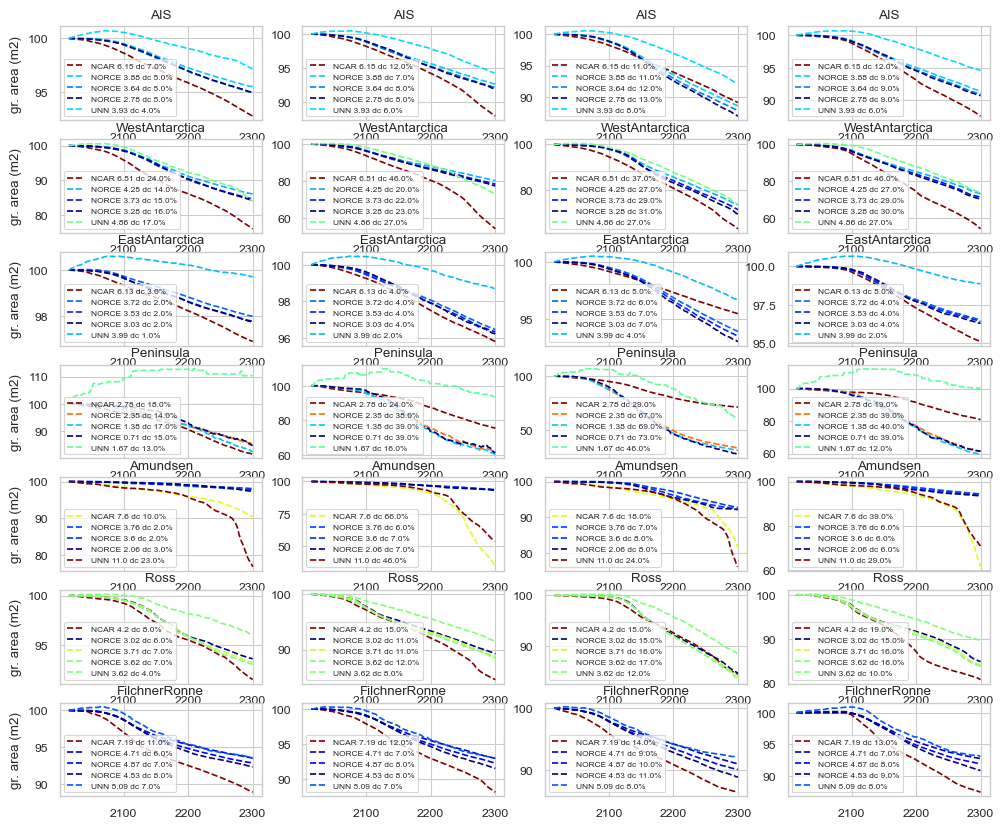

In [20]:
# 2. RO Quad. Local

Models_1 = ['NCAR_CISM2', 'NORCE_CISM3-MAR364-ERA-t1-local' ,'NORCE_CISM4-MAR364-ERA-t1-local' ,'NORCE_CISM5-MAR364-ERA-t1-local', 'UNN_Ua']

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms} dc {decline}%')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr. area (m2)')
   




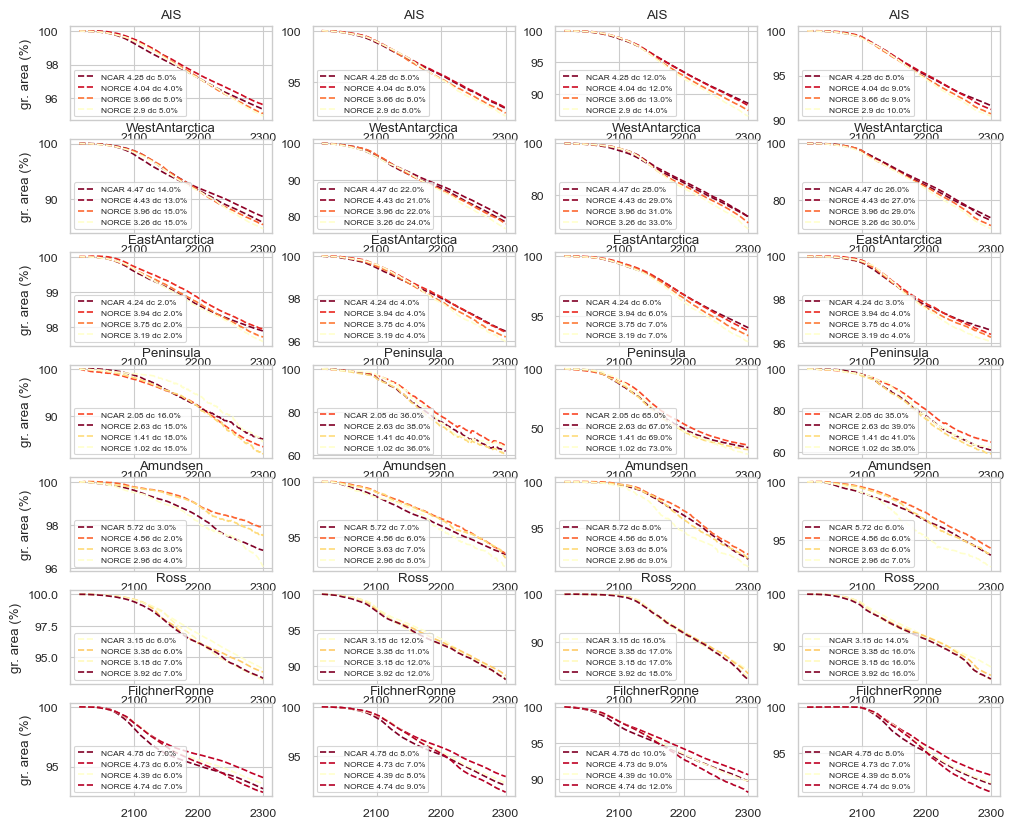

In [21]:
# 3.  Ro Quad. Non-local 

Models_1 = ['NCAR_CISM1' ,'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' ,'NORCE_CISM5-MAR364-ERA-t1-nonlocal']

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('YlOrRd')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms} dc {decline}%')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr. area (%)')
   




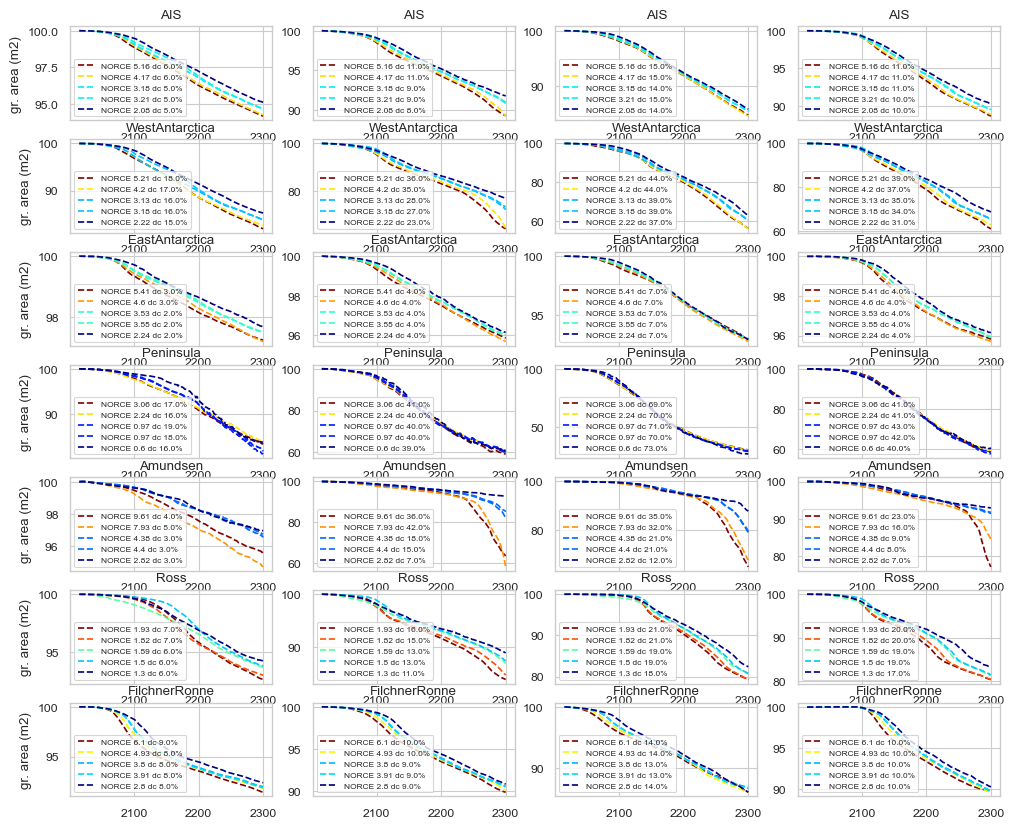

In [22]:
# 3.  Ro Quad. Non-local slope

Models_1 = ['NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1',
 'NORCE_CISM4-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-JRA-t1',
 'NORCE_CISM5-MAR364-ERA-t1']

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models_1):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--' ,label =f'{Pre_mod} {ms} dc {decline}%')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr. area (m2)')
   




In [23]:
Models_1.size

AttributeError: 'list' object has no attribute 'size'

In [ ]:
ms_models

### can we group RO only toegther with ms? NO

In [ ]:
# 3.  Ro Quad. all
Models_1 = ['NCAR_CISM1' ,'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' ,'NORCE_CISM5-MAR364-ERA-t1-nonlocal',\
'NCAR_CISM2', 'NORCE_CISM3-MAR364-ERA-t1-local' ,'NORCE_CISM4-MAR364-ERA-t1-local' ,\
            'NORCE_CISM5-MAR364-ERA-t1-local', 'UNN_Ua',\
           'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1',
 'NORCE_CISM4-MAR364-ERA-t1', 'NORCE_CISM4-MAR364-JRA-t1',
 'NORCE_CISM5-MAR364-ERA-t1',
           ]


mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,14))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('YlOrRd')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models[mask_special_model]):
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[0]
            ax.plot(d.time.values,y,color = col,linestyle = '--',label =f' {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr area (%)')
   




### now let us look if we can group other things together... , fix clacing front, all PICO , all

 ##### STIR lin STIR pico

In [ ]:
# 3.  Ro Quad. Non-local 
Models_1 = ['VUW_PISM1' , 'VUW_PISM1_s2', 'VUW_PISM1_s3' ,'VUW_PISM1_s4',
 'VUW_PISM2' ,'VUW_PISM2_s1','VUW_PISM2_s2' ,'VUW_PISM2_s3', 'VUW_PISM2_s4',\
          'PIK_PISM' ]

mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models[mask_special_model]):
#             print*Mo
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
#             print(ms)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[-1]
            if Model == 'PIK_PISM':
                ax.plot(d.time.values,y,color = col,linestyle = 'solid',label =f'{Pre_mod} {ms}')
            else:
                ax.plot(d.time.values,y,color = col,linestyle = 'dotted',label =f'{Pre_mod} {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr. area (%)')
   




### let us looke  at fix cf

In [ ]:
# 3.  Ro Quad. Non-local 
Models_1 = ['IGE_ElmerIce','UCSD_ISSM','UTAS_ElmerIce']


mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models[mask_special_model]):
#             print*Mo
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
#             print(ms)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[-1]
            if Model == 'PIK_PISM':
                ax.plot(d.time.values,y,color = col,linestyle = 'solid',label =f'{Pre_mod} {ms}')
            else:
                ax.plot(d.time.values,y,color = col,linestyle = 'dotted',label =f'{Model} {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr. area (%)')
   




### DIV (hydrofracture and cliff failure) pico and quad lcoal 

In [ ]:
# 3.  Ro Quad. Non-local 
Models_1 = ['ULB_fETISh-KoriBU1','ULB_fETISh-KoriBU2']


mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models[mask_special_model]):
#             print*Mo
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
#             print(ms)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[-1]
            if Model == 'PIK_PISM':
                ax.plot(d.time.values,y,color = col,linestyle = 'solid',label =f'{Pre_mod} {ms}')
            else:
                ax.plot(d.time.values,y,color = col,linestyle = 'dotted',label =f'{Pre_mod} {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr. farea (%)')
   




Div PICO<br>
Models ['ULB_fETISh-KoriBU1']<br>
Div Quad. Non-local<br>
Models ['ULB_fETISh-KoriBU2']<br>
Fix PICO<br>
Models ['IGE_ElmerIce']<br>
Fix PICOP<br>
Models ['UCSD_ISSM']<br>
Fix Quad. Local<br>
Models ['UTAS_ElmerIce']<br>
MH Quad. Non-local<br>
Models ['DC_ISSM' 'ILTS_SICOPOLIS' 'LSCE_GRISLI2' 'LSCE_GRISLI' 'VUB_AISMPALEO']<br>
RO Quad. Local<br>
Models ['NCAR_CISM2' 'NORCE_CISM3-MAR364-ERA-t1-local'
 'NORCE_CISM4-MAR364-ERA-t1-local' 'NORCE_CISM5-MAR364-ERA-t1-local'
 'UNN_Ua']<br>
RO Quad. Non-local<br>
Models ['NCAR_CISM1' 'NORCE_CISM3-MAR364-ERA-t1-nonlocal'
 'NORCE_CISM4-MAR364-ERA-t1-nonlocal' 'NORCE_CISM5-MAR364-ERA-t1-nonlocal']<br>
RO Quad. Non-local Slope<br>
Models ['NORCE_CISM2-MAR364-ERA-t1' 'NORCE_CISM3-MAR364-ERA-t1'
 'NORCE_CISM4-MAR364-ERA-t1' 'NORCE_CISM4-MAR364-JRA-t1'
 'NORCE_CISM5-MAR364-ERA-t1']<br>
StR Lin<br>
Models ['VUW_PISM1' 'VUW_PISM1_s1' 'VUW_PISM1_s2' 'VUW_PISM1_s3' 'VUW_PISM1_s4'
 'VUW_PISM2' 'VUW_PISM2_s1' 'VUW_PISM2_s2' 'VUW_PISM2_s3' 'VUW_PISM2_s4']<br>
StR PICO<br>
Models ['PIK_PISM']<br>
VM Quad. Non-local<br>
Models ['UCM_Yelmo']<br>

In [24]:
df_best['melt_sensetivity_Amundsen']

0      9.183323
1      2.831167
2     12.734657
3     12.105475
4     12.657794
5      5.717034
6      7.597750
7      9.607826
8      3.755640
9      4.557420
10     7.925523
11     3.596986
12     3.630585
13     4.375989
14     4.396734
15     2.056184
16     2.961624
17     2.824266
18    11.130462
19     5.999634
20     0.781363
21     4.340304
22    11.668598
23    10.998067
24     9.313539
25     2.029031
26    13.818903
27    14.991803
28    13.020984
29    13.937739
30    13.710917
31    14.039431
32    13.771195
33    13.423226
34    13.897126
35    15.824245
Name: melt_sensetivity_Amundsen, dtype: float64

In [25]:
df_best.Model

0                                DC_ISSM
1                           IGE_ElmerIce
2                         ILTS_SICOPOLIS
3                           LSCE_GRISLI2
4                            LSCE_GRISLI
5                             NCAR_CISM1
6                             NCAR_CISM2
7              NORCE_CISM2-MAR364-ERA-t1
8        NORCE_CISM3-MAR364-ERA-t1-local
9     NORCE_CISM3-MAR364-ERA-t1-nonlocal
10             NORCE_CISM3-MAR364-ERA-t1
11       NORCE_CISM4-MAR364-ERA-t1-local
12    NORCE_CISM4-MAR364-ERA-t1-nonlocal
13             NORCE_CISM4-MAR364-ERA-t1
14             NORCE_CISM4-MAR364-JRA-t1
15       NORCE_CISM5-MAR364-ERA-t1-local
16    NORCE_CISM5-MAR364-ERA-t1-nonlocal
17             NORCE_CISM5-MAR364-ERA-t1
18                              PIK_PISM
19                             UCM_Yelmo
20                             UCSD_ISSM
21                    ULB_fETISh-KoriBU1
22                    ULB_fETISh-KoriBU2
23                                UNN_Ua
24              

### ALL PICO


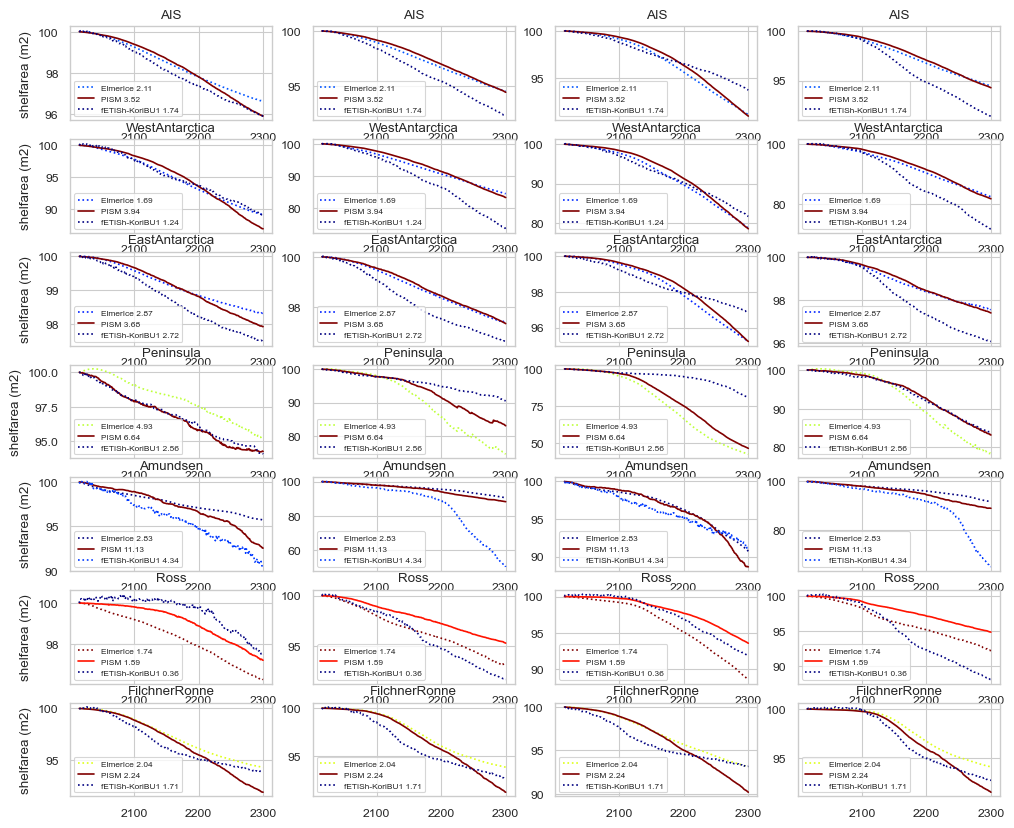

In [26]:
# 3.  Ro Quad. Non-local 
Models_1 =  ['ULB_fETISh-KoriBU1' ,'IGE_ElmerIce','PIK_PISM']


mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models[mask_special_model]):
#             print*Mo
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
#             print(ms)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[-1]
            if Model == 'PIK_PISM':
                ax.plot(d.time.values,y,color = col,linestyle = 'solid',label =f'{Pre_mod} {ms}')
            else:
                ax.plot(d.time.values,y,color = col,linestyle = 'dotted',label =f'{Pre_mod} {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('shelfarea (m2)')
   




### all quad non local

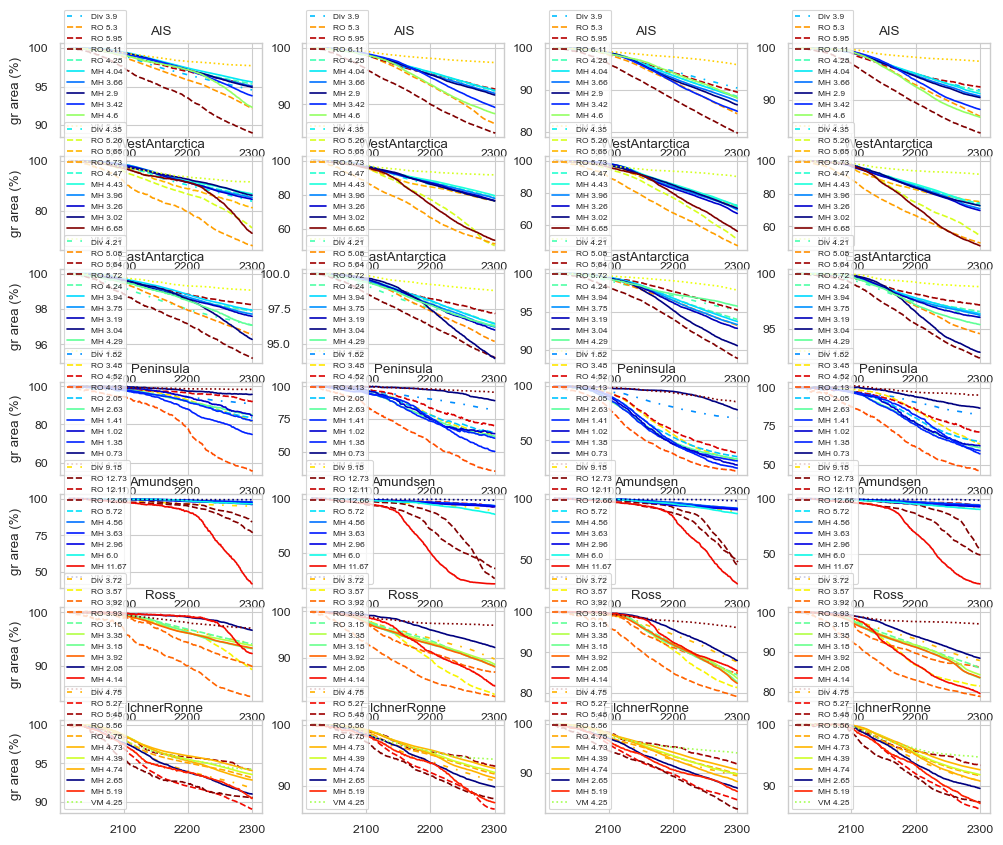

In [27]:
# 3.  Ro Quad. Non-local 
Models_1 =  ['ULB_fETISh-KoriBU2' , 'NCAR_CISM1', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal',
             'NORCE_CISM4-MAR364-ERA-t1-nonlocal' ,'NORCE_CISM5-MAR364-ERA-t1-nonlocal',\
             'DC_ISSM', 'ILTS_SICOPOLIS' ,'LSCE_GRISLI2' ,'LSCE_GRISLI' ,'VUB_AISMPALEO','UCM_Yelmo']
CFs = ['Div','RO','RO','RO','RO','MH' ,'MH' ,'MH' ,'MH' ,'MH' ,'VM']
dic_cd_linestyle ={}
dic_cd_linestyle['Div']=(0, (3, 5, 1, 5))
dic_cd_linestyle['VM']='dotted'
dic_cd_linestyle['RO']='dashed'
dic_cd_linestyle['MH']='solid'



mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models[mask_special_model]):
#             print*Mo
            cf =CFs[k]
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
#             print(ms)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[-1]
        
            ax.plot(d.time.values,y,color = col,linestyle = dic_cd_linestyle[cf],label =f'{cf} {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr area (%)')
   




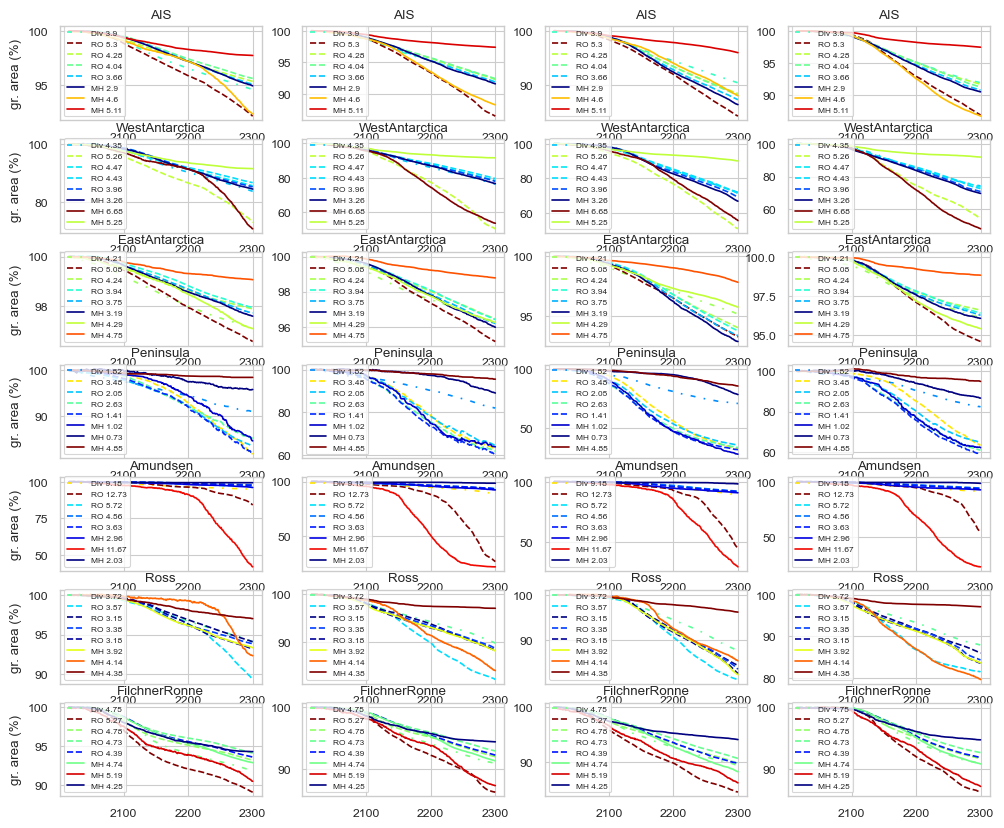

In [28]:
# 3.  Ro Quad. Non-local 
Models_1 =  ['ULB_fETISh-KoriBU2' , 'NCAR_CISM1', 'NORCE_CISM3-MAR364-ERA-t1-nonlocal',
             'NORCE_CISM4-MAR364-ERA-t1-nonlocal' ,'NORCE_CISM5-MAR364-ERA-t1-nonlocal',\
             'DC_ISSM', 'ILTS_SICOPOLIS'  ,'VUB_AISMPALEO']
CFs = ['Div','RO','RO','RO','RO','MH' ,'MH' ,'MH' ]
dic_cd_linestyle ={}
dic_cd_linestyle['Div']=(0, (3, 5, 1, 5))
dic_cd_linestyle['VM']='dotted'
dic_cd_linestyle['RO']='dashed'
dic_cd_linestyle['MH']='solid'



mask_special_model =Models=='notamodel'
for i,Model in enumerate(Models):
    for spec_model in Models_1:
        if spec_model == Model:
            mask_special_model[i]= 'True'
            
            



f, ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
for i,region in  enumerate(regions):
    ms_models = df_best[f'melt_sensetivity_{region}'].values[mask_special_model]
    
    norm = Normalize(vmin=ms_models.min(), vmax=ms_models.max())
    normalized_ms = norm(ms_models)

    # Apply the colormap 'YlOrRd'
    cmap = plt.get_cmap('jet')
    colors = cmap(normalized_ms)

    for j,  exp in enumerate(expnames):
        df_bmb2100_exp = df_bmb2100[df_bmb2100.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        for k,Model in enumerate(Models[mask_special_model]):
#             print*Mo
            cf =CFs[k]
            df_model =df_bmb2100_exp[df_bmb2100_exp.Model == Model]
            new_path =   df_model.Path.values[0].replace('shelfmelt', 'iareagr')
            d = xr.open_dataset(new_path,decode_times=False )
            y = 0
            area = 0
            for key  in regions_keys[region]:
                melt = d[f'iareagr{key}'].values
                y = y+melt
            y = y/y[0]*100
            decline = np.round(y.max() -y.min())
            ms = np.round(ms_models[k],2)
#             print(ms)
            col = colors[k]
            
            
            if (exp == 'expAE02') & ( Model == 'VUW_PISM1_s1'):
                continue
            
            Pre_mod = Model.split('_')[-1]
        
            ax.plot(d.time.values,y,color = col,linestyle = dic_cd_linestyle[cf],label =f'{cf} {ms}')
            ax.legend(loc=3,fontsize = 6)
        ax.set_title(f'{region}')  
    ax2[i,0].set_ylabel('gr. area (%)')
   




In [22]:

##### Amundsen sea sector

the Amundesne sec sector behaves wuite uniylis as there is in some case strong growth  of the gheodl  
\\\\\\\\\\\\N MN